In [ ]:
from google.colab import drive
drive.mount("/content/drive")#, force_remount=True)

Mounted at /content/drive


In [ ]:
output_dir = "/content/drive/MyDrive/Colab Notebooks/rakuten"

In [ ]:
import sys
sys.path.insert(0,'/content/drive/MyDrive/Colab Notebooks/rakuten')

In [ ]:
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/rakuten")

In [ ]:
%ls

 adam.py                                       pruner.py
 albert/                                       pruners.py
 albert-old/                                  'Pruning ALBERT.ipynb'
 Cifar_CNN.ipynb                              'Pruning LLaMA.ipynb'
 dataset/                                     'Pruning with Keras.ipynb'
 diabetes.txt                                  __pycache__/
 genetic_adam.py                               rmsProp.py
 genetic_algorithm_code.py                     run_results.csv
 hooks.py                                      sgd.py
'Hyperparameter Optimization using GA.ipynb'  'Training CNN using GA.ipynb'
 model/                                        training_losses.png
 model_f/                                      Untitled0.ipynb
 model.py                                      utils.py


In [ ]:
import os

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.adamw import AdamW
from model import GPT
from utils import BatchLoader, experiment, save, train_loop

In [ ]:
# hyperparameters
batch_size = 16
block_size = 128  # maximum context length
max_iters = 10000
eval_interval = 500
learning_rate = 3e-4
device = ("cuda" if torch.cuda.is_available() else "cpu")

eval_iters = 500
n_embd = 256
n_head = 4
n_blocks = 4
dropout = 0.2

torch.manual_seed(1337)
print(device)

cuda


In [ ]:
class Tokenizer:
    def __init__(self, chars: list[str]):
        self.stoi = {s: i for i, s in enumerate(chars)}
        self.itos = {v: k for k, v in self.stoi.items()}

    def encode(self, text: str) -> list[int]:
        return [self.stoi[c] for c in text]

    def decode(self, ixs: list[int]) -> str:
        return "".join([self.itos[ix] for ix in ixs])

In [ ]:
# data preparation
text = open("dataset/tinyshakespeare.txt", "r").read()
# set up the vocabulary
chars = sorted(list(set(text)))
vocab_size = len(chars)
# create a mapping from characters to integers
tokenizer = Tokenizer(chars)

data = torch.tensor(tokenizer.encode(text), dtype=torch.long)

n = int(0.9 * len(data))  # first 90% will be the training set
n1 = int(
    0.95 * len(data)
)  # 90-95% will be the validation set and the last 5% will be the calibration set for the paper

train_data = data[:n]
val_data = data[n:n1]
calibrate_data = data[n1:]

train_loader = BatchLoader(train_data, block_size, batch_size, device, name="train")
val_loader = BatchLoader(val_data, block_size, batch_size, device, name="val")
calibration_loader = BatchLoader(
    calibrate_data, block_size, batch_size, device, name="calibrate"
)
model = GPT(vocab_size, block_size, n_embd, n_head, n_blocks, device, dropout)
model.to(device)

optimizer = AdamW(model.parameters(), lr=learning_rate)

In [ ]:
calibration_loader

In [ ]:
print(calibration_loader.data)

tensor([56, 39, 52,  ..., 45,  8,  0])


UNIFORM BASELINE:  4.174387454986572


  0%|          | 0/10000 [00:00<?, ?it/s]

training is done!
[0.6329220533370972, 0.59250807762146, 0.5627433657646179, 0.5495333671569824, 0.525678277015686, 0.5226050019264221, 0.5083762407302856, 0.5053209662437439, 0.5102514028549194, 0.5120529532432556, 0.49679461121559143, 0.49078285694122314, 0.49703577160835266, 0.48920878767967224, 0.4872417151927948, 0.4852713644504547, 0.47092127799987793, 0.5143511295318604, 0.47942450642585754, 0.4822666347026825, 0.4642148017883301, 0.46532052755355835, 0.46131959557533264, 0.4690568745136261, 0.47128015756607056, 0.455126017332077, 0.45479369163513184, 0.45591387152671814, 0.4637715816497803, 0.44316384196281433, 0.46532106399536133, 0.4559687077999115, 0.4425082206726074, 0.4615575969219208, 0.44889846444129944, 0.44521188735961914, 0.44628363847732544, 0.436397522687912, 0.43427684903144836, 0.44916069507598877, 0.4341873824596405, 0.438880980014801, 0.4276944398880005, 0.45689910650253296, 0.4340148866176605, 0.42644453048706055, 0.42462974786758423, 0.4237716794013977, 0.4295

  0%|          | 0/200 [00:00<?, ?it/s]

Pruned evaluation loss (after calibration):                  2.0749


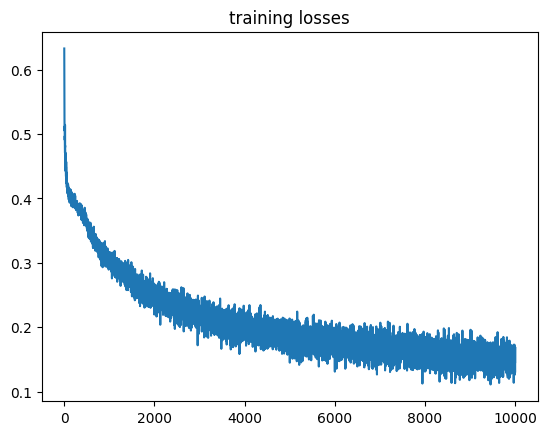

In [ ]:
training_losses = train_loop(
    model,
    optimizer,
    vocab_size,
    train_loader,
    [train_loader, val_loader],
    max_iters,
    eval_interval,
    eval_iters,
)

print("training is done!")

plt.title("training losses")
plt.plot(training_losses)
plt.savefig("training_losses.png")
print(training_losses)
idx = torch.zeros((1, 1), dtype=torch.long, device=device)
print(tokenizer.decode(model.generate(idx, max_new_tokens=800)[0].tolist()))

model_params = {
    "params": {
    "vocab_size": vocab_size,
    "block_size": block_size,
    "n_embd": n_embd,
    "n_head": n_head,
    "n_blocks": n_blocks,
    "dropout": dropout,
    "device": device,
    }
}

save(model, tokenizer, model_params, "model_for_10k_iters")

print("-" * 50)
print("The experiment is going to start soon!")

# configurations = get_config_combinations()[:-2]
configurations = [
    [
        ("width_head", 0.2),
        ("width_neuron", 0.2),
        ("width_embedding", 0.2),
    ]
]


results = experiment(
    batch_size,
    block_size,
    vocab_size,
    calibration_loader,
    val_loader,
    device=device,
    pruning_strategies=configurations,
    learning_rate=learning_rate,
    model_path="./model_for_10k_iters",
)

In [ ]:
for i in range(5):
  print("Trial ",i+1)
  idx = torch.zeros((1, 1), dtype=torch.long, device=device)
  print(tokenizer.decode(model.generate(idx, max_new_tokens=800)[0].tolist()))

Trial  1

CLARENCE:
Comfort and speased be
pack of the lamiter stremnks of that is thoughts.

CLARD:
O, thou shame wast doth man him, he was
himmion to this heighbour plocox formigoty:
And, not these are end of this another?

Prison:
O my gilted up the head witter the capp'd of love;
And leaving poor his rely and with virtuous,
That had tcheer thee pride betch o'er
My bropal, orget-has plinty.
O, take your moteous, have you, help?

ToSigons:
House that a king, madam, his, to angry else.

SLY:
Thy made it lass as you be took him? but by my swear of here!

Post:
Tranio! I prayer thou loinness on that staff'd our Lord of Scope?
O, good thy contendentess help to pray that
Wan flates of your tong to puts
With oath!gill his ehell'd, nor no, reger--bands
To live his, as canside as fly con's head;
How well,
Trial  2

And sing for I more oravel, like or waten.

MISTRANIO:
There's citizens your worn silench a presume or
Your sonier, ye eld nexturied your condembred good
Therefore: good and your 

In [ ]:
for i in range(5):
  print('-----------------------------'*4)
  print("Trial ",i+1)
  idx = torch.zeros((1, 1), dtype=torch.long, device=device)
  print(tokenizer.decode(model.generate(idx, max_new_tokens=800)[0].tolist()))

--------------------------------------------------------------------------------------------------------------------
Trial  1


ISABELLA:
Aem the that huns and my breel heavens, wislip a more
But fiting before anger of it had
call heaved a hange enough. Rever horse, I'll can
We hear a foolment of prison abot our prece,
Conservery; Beling elthee, by part up,
And rever Romeo-mole of a great gently,
And I have well cannot your--protch answer,
That I serve stand up thy not of Edward?
Reated the cection form what threet and case his sun
Of the is bell hault the forger's fairly Frilling frired.

LEONTES:
Beness'd forth at king this,
But him hasdemdless of Hereous the chastigion;
She pased
Grooping the countableth of hand, silence and
This in than ears all, insparies. Thou such follow proborc.

ClRIOLANUS:
Now Waptumes Aufire.'

CORIOLANUS:
It is she did more to say not not with
shall we lonk, only affoious to the lewsid
------------------------------------------------------------------------

In [ ]:
save(model, tokenizer, model_params, "model_final_10k_iters")

## outputs for 5000 iterations

In [ ]:
idx = torch.zeros((1, 1), dtype=torch.long, device=device)
print(tokenizer.decode(model.generate(idx, max_new_tokens=800)[0].tolist()))


Alas, poice it days.
Shall the she gother: I may my lord?

LEONTES:
My come of sir the gall, that exore in deceive?

BIANGBROK:
There, sir, as we him e'er nother court what's
Fouring his and than everle, to have tigue bad; I ral ever
sout pomper fatheritly so. My lorvan, by even lents, of with
A did say not speal, that my fear?

GLOUCESTER:
Clarown:
My Glory viols of exight. You, go see's, gust upingly,
Last said like hepprients breath? wo
all lebut sever
All live high many Ble, you humay to go Xive,
As not make I saborjory Claughts, that gries and merped
With child of his will him.

FRIAR HENRY BOLINGMERD:
Trive I'll no;'t in my somet's not.

HENRY BOLINGBROKE:

Alamens:
Them.

EXBUS:
Well imalick, now, be nexk where,
Scontided it me; my am, blood, my sillier in; tell,
Is good as crown gi


In [ ]:
idx = torch.zeros((1, 1), dtype=torch.long, device=device)
print(tokenizer.decode(model.generate(idx, max_new_tokens=800)[0].tolist()))


Twe tribund this silk in mistrenge:
I brow not screture purple, thing Aufisa!
If as grently, thy brows!

ABTINTIGOBENELLO:
Have we have presentlement
YORK: pon you men plemine and on on so,
If In twhich I given ithurt had shall how lest my breast.

LADY GORY BOLIENGBROKE:
I worthnef, how me, here the dam-pardy nock.

ORCENTES:
Mint ide enought, not runghtming?

DUKE LEOWPS?
You was thou to him now; ir with? is Aly, and and be
stare'em.

PLADY CAPULET:
Not bete good:
Loar the gone this Cll! What, aftear's great.

LADY CANTIS:
Ah, speak so!

CORIOLANUS:
Sast tongue with By my born'd, cheeds a, sir,
Sad allonk you Rome, our mark nows, your mercy: appoaunably.

LEONTEGS:
Far, and my very whill dell happdly I had one emord.

FARINCE:
Then, oe'ere heard hath track.

DUKE VI:
He saves in own, whe


In [ ]:
from utils import save, load

In [ ]:
save(model, tokenizer, model_params, "model_f")